# **Build a Deep Research Agent with LangGraph**


Build an AI-powered deep research agent that can autonomously search the web, analyze information from multiple sources, and synthesize comprehensive research reports on any topic! This hands-on project will teach you to build a multi-step agentic workflow using LangGraph, OpenAI's GPT models, and the Tavily search API. You'll learn to design agent state, create specialized processing nodes, and orchestrate them into a powerful research pipeline.

Here's your challenge: You've been approached by "InsightAI," an analytics consultancy that wants to automate their preliminary research process. Their lead analyst explains: "Our team spends hours manually searching for information, reading through dozens of articles, and compiling findings into structured reports. We need an intelligent agent that can take a research question, autonomously gather information from the web, critically analyze what it finds, and produce a well-organized research report — saving our analysts hours of tedious groundwork."

You'll solve this by building a deep research agent using LangGraph, a framework for building stateful, multi-step AI workflows. Your agent will plan research queries, search the web using Tavily, extract and analyze key findings, and generate a polished research report — transforming a manual, time-consuming process into an automated, intelligent pipeline.


## Learning Objectives

After completing this lab you will be able to:
- Build a multi-step research agent using LangGraph and OpenAI's GPT models
- Design and manage complex agent state with TypedDict schemas
- Integrate web search capabilities using the Tavily API
- Create specialized agent nodes for planning, researching, analyzing, and writing
- Orchestrate nodes into a stateful graph with conditional edges
- Generate structured, well-sourced research reports automatically


## Setup


For this lab, we will be using the following libraries:

* [`openai`](https://platform.openai.com/docs/) for making calls to GPT models
* [`langgraph`](https://langchain-ai.github.io/langgraph/) for building the multi-step agent graph
* [`langchain-openai`](https://python.langchain.com/docs/integrations/llms/openai/) for LangChain's OpenAI integration
* [`tavily-python`](https://docs.tavily.com/) for performing web searches
* [`langchain-core`](https://python.langchain.com/docs/) for core LangChain abstractions


### Installing Required Libraries

(Installing the libraries may take up to 2 minutes)


In [3]:
%%capture
%pip install openai==1.82.0 | tail -n 1
%pip install tavily-python==0.5.4 | tail -n 1
%pip install langgraph==0.4.1 | tail -n 1
%pip install langchain-openai==0.3.18 | tail -n 1

### Importing Required Libraries


In [4]:
import warnings
warnings.filterwarnings('ignore')

import os
import json
from datetime import datetime
from typing import Dict, List, TypedDict, Annotated

from openai import OpenAI
from tavily import TavilyClient
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import HumanMessage, SystemMessage

### Keyword Dictionary

Before we start writing code, let's make sure we're on the same page. Below you'll find a word bank of all the important terms you'll need to know in order to meaningfully work through this guided project.

| Term | Definition |
|------|------------|
| **LLM (Large Language Model)** | A neural network trained on massive text data that can generate, summarize, and reason about text. GPT-4o-mini is the LLM we use in this project. |
| **Agent** | An AI system that can autonomously decide what actions to take, execute those actions, and use the results to inform its next steps. |
| **LangGraph** | A framework built on top of LangChain for building stateful, multi-step AI workflows as directed graphs. Nodes are processing steps, edges define the flow. |
| **State** | A shared data structure (TypedDict) that is passed between nodes in the graph, accumulating information as the agent progresses through its workflow. |
| **Node** | A single processing step in a LangGraph workflow. Each node is a Python function that takes the current state, performs an action, and returns an updated state. |
| **Edge** | A connection between nodes that defines the order of execution. Edges can be unconditional (always follow) or conditional (choose next node based on state). |
| **Tavily** | A search API purpose-built for AI agents. It returns clean, structured search results optimized for LLM consumption, unlike raw web scraping. |
| **Prompt Engineering** | The practice of crafting input prompts to guide an LLM toward producing a specific, high-quality output. Critical for each node in our agent. |
| **Research Query Decomposition** | Breaking a broad research question into smaller, targeted sub-queries that can each be searched independently for more thorough coverage. |
| **Synthesis** | The process of combining information from multiple sources into a coherent, unified analysis that is greater than the sum of its parts. |


## Project Roadmap

### Deep Research Agent Overview

A deep research agent automates the process of investigating a topic by breaking it into a multi-step pipeline. Instead of relying on a single LLM call, the agent orchestrates multiple specialized steps, each focused on a specific part of the research process:

- **Query Planning**: Decomposing a broad research question into targeted sub-queries
- **Web Research**: Searching the web for each sub-query and collecting relevant results
- **Analysis**: Critically evaluating and synthesizing the gathered information
- **Report Writing**: Producing a structured, well-sourced research report

This approach mirrors how human researchers work — they don't just Google a question once. They break it down, search multiple angles, cross-reference sources, and compile their findings.


---
### LangGraph Architecture

LangGraph models AI workflows as **directed graphs**. Here's why this matters for our research agent:

- **Stateful Execution**: Unlike a simple chain of LLM calls, LangGraph maintains a shared state object that nodes can read from and write to. This means our analyzer node can access raw search results collected by the researcher node.
- **Flexible Control Flow**: Edges between nodes can be conditional. For example, if the researcher finds insufficient results, the agent can loop back to generate more queries.
- **Modular Design**: Each node is an independent function. You can swap in a different search provider, change your LLM, or add new processing steps without rewriting the entire pipeline.

Our research graph will look like this:

```
[START] --> [Plan Queries] --> [Research] --> [Analyze] --> [Write Report] --> [END]
```

Each box is a **node** (a Python function), and each arrow is an **edge** (the flow of execution).


### Implementation Strategy

Our approach:
1. **Set Up the LLM and Search Tool**: Configure OpenAI GPT-4o-mini and the Tavily search client
2. **Define the Agent State**: Create a TypedDict schema that tracks everything the agent learns
3. **Build the Nodes**: Implement each processing step — planning, researching, analyzing, and writing
4. **Assemble the Graph**: Wire the nodes together with edges using LangGraph's StateGraph
5. **Run the Agent**: Execute the graph on a research question and get a complete report


## Building the Deep Research Agent

### Setting Up the LLM and Search Tool

We'll use OpenAI's GPT-4o-mini as our LLM (fast, capable, and cost-effective) and Tavily as our search engine (designed specifically for AI agents — it returns clean, structured results rather than raw HTML).


### Understanding the API Setup

Before we initialize our tools, let's understand what each client does:

### OpenAI Client
- **Purpose**: Sends prompts to GPT-4o-mini and receives generated text back
- **How it works**: We send a system message (role/instructions) and a user message (the actual task), and the model returns a completion
- **Why GPT-4o-mini**: It strikes the best balance of speed, quality, and cost for a research agent that makes many LLM calls

### Tavily Client
- **Purpose**: Searches the web and returns structured results (title, URL, content snippet)
- **How it works**: We send a search query and get back a list of relevant results with extracted content
- **Why Tavily over Google**: Tavily is built for AI agents — results are pre-cleaned, relevant, and formatted for LLM consumption. No need to scrape HTML.


### Configuring the API Keys

To use the Tavily API, you'll need an API key. Set it as an environment variables below. An OpenAI key is not needed as it is automatically available in Skills Network labs. 

- **Tavily API Key**: Get one at [app.tavily.com](https://app.tavily.com) (free tier available)


In [8]:
# Set your API key here
os.environ["TAVILY_API_KEY"] = "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"

# Initialize the OpenAI client
openai_client = OpenAI()

# Initialize the Tavily search client
tavily_client = TavilyClient()

# Initialize the LangChain ChatOpenAI wrapper (used by LangGraph nodes)
llm = ChatOpenAI(model="gpt-4o-mini", temperature=0.3)

print("OpenAI client initialized.")
print("Tavily client initialized.")
print("LangChain LLM wrapper initialized.")
print(f"Model: gpt-4o-mini")

OpenAI client initialized.
Tavily client initialized.
LangChain LLM wrapper initialized.
Model: gpt-4o-mini


### Testing the Connections

Before building the full agent, let's verify both APIs are working. We'll send a simple test query to each.


In [9]:
# Test the OpenAI connection
print("Testing OpenAI connection...")
test_response = openai_client.chat.completions.create(
    model="gpt-4o-mini",
    messages=[{"role": "user", "content": "Say 'connection successful' in exactly two words."}],
    max_tokens=10
)
print(f"OpenAI response: {test_response.choices[0].message.content}")

# Test the Tavily connection
print("\nTesting Tavily connection...")
test_search = tavily_client.search(query="What is LangGraph?", max_results=1)
print(f"Tavily returned {len(test_search['results'])} result(s)")
print(f"Top result: {test_search['results'][0]['title']}")

print("\nAll connections verified!")

Testing OpenAI connection...
OpenAI response: Connection established.

Testing Tavily connection...
Tavily returned 1 result(s)
Top result: What is LangGraph - GeeksforGeeks

All connections verified!


### Defining the Agent State

The agent state is the backbone of our LangGraph workflow. It's a shared data structure that flows through every node, accumulating information as the agent progresses through its research pipeline.

Think of it like a research assistant's notebook — as they move through each phase (planning, researching, analyzing, writing), they jot down their findings, and the notebook travels with them to the next step.

We define the state as a `TypedDict`, which gives us type safety and clear documentation of what data the agent tracks.


In [10]:
class ResearchState(TypedDict):
    """State schema for the deep research agent.
    
    This TypedDict defines every piece of data the agent tracks
    as it moves through the research pipeline.
    """
    # The original research question from the user
    research_question: str
    
    # Sub-queries generated by the planner node
    search_queries: List[str]
    
    # Raw search results from Tavily (list of dicts with title, url, content)
    search_results: List[Dict]
    
    # Synthesized analysis of the search results
    analysis: str
    
    # The final research report
    report: str
    
    # List of source URLs used in the research
    sources: List[str]

print("ResearchState schema defined.")
print("Fields: research_question, search_queries, search_results, analysis, report, sources")

ResearchState schema defined.
Fields: research_question, search_queries, search_results, analysis, report, sources


### Understanding the State Schema

Let's break down each field in our `ResearchState`:

| Field | Type | Set By | Purpose |
|-------|------|--------|---------|
| `research_question` | `str` | User input | The original question we're researching |
| `search_queries` | `List[str]` | Planner node | Targeted sub-queries derived from the main question |
| `search_results` | `List[Dict]` | Researcher node | Raw results from Tavily web searches |
| `analysis` | `str` | Analyzer node | Synthesized insights from the raw results |
| `report` | `str` | Writer node | The final, formatted research report |
| `sources` | `List[str]` | Researcher node | URLs of all sources consulted |

Notice how each node reads from earlier fields and writes to its own. This is the power of LangGraph's shared state — it enables loose coupling between nodes while maintaining a clear data flow.


### Building the Query Planner Node

The first node in our pipeline is the **query planner**. Its job is to take the user's broad research question and break it into specific, targeted sub-queries. This is a crucial step — good sub-queries lead to better search results, which lead to a better final report.

For example, if the user asks:
> "What are the latest developments in quantum computing?"

The planner might generate:
1. "quantum computing breakthroughs 2025"
2. "major quantum computing companies and progress"
3. "quantum computing practical applications current"
4. "quantum computing challenges and limitations"


In [11]:
def plan_queries(state: ResearchState) -> dict:
    """Generate targeted sub-queries from the main research question.
    
    This node uses the LLM to decompose a broad research question into
    3-5 specific search queries that will cover different angles of the topic.
    
    Args:
        state (ResearchState): Current agent state with research_question.
        
    Returns:
        dict: Updated state with search_queries populated.
    """
    question = state["research_question"]
    
    # Use the LLM to generate sub-queries
    response = openai_client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {
                "role": "system",
                "content": (
                    "You are a research query planner. Given a research question, "
                    "generate 3-5 specific search queries that together will provide "
                    "comprehensive coverage of the topic. Each query should target a "
                    "different angle or aspect.\n\n"
                    "Return ONLY a JSON array of strings. No explanation, no markdown.\n"
                    "Example: [\"query 1\", \"query 2\", \"query 3\"]"
                )
            },
            {
                "role": "user",
                "content": f"Research question: {question}"
            }
        ],
        temperature=0.4
    )
    
    # Parse the JSON array of queries from the LLM response
    queries = json.loads(response.choices[0].message.content)
    
    print(f"Planned {len(queries)} sub-queries:")
    for i, q in enumerate(queries, 1):
        print(f"  {i}. {q}")
    
    return {"search_queries": queries}

print("Query planner node defined.")

Query planner node defined.


### Building the Web Researcher Node

The researcher node takes the sub-queries generated by the planner and executes web searches for each one using Tavily. It collects all results and source URLs into the shared state.

This node is the agent's "eyes and ears" — it's responsible for gathering all the raw information that later nodes will process.


In [12]:
def research(state: ResearchState) -> dict:
    """Execute web searches for each planned sub-query.
    
    This node uses the Tavily API to search the web for each sub-query
    generated by the planner. It collects all results and source URLs.
    
    Args:
        state (ResearchState): Current state with search_queries populated.
        
    Returns:
        dict: Updated state with search_results and sources populated.
    """
    queries = state["search_queries"]
    all_results = []
    all_sources = []
    
    for i, query in enumerate(queries, 1):
        print(f"Searching ({i}/{len(queries)}): {query}")
        
        # Execute the search using Tavily
        search_response = tavily_client.search(
            query=query,
            max_results=3,          # 3 results per sub-query
            search_depth="advanced"  # More thorough search
        )
        
        # Process each result
        for result in search_response["results"]:
            all_results.append({
                "query": query,
                "title": result["title"],
                "url": result["url"],
                "content": result["content"]
            })
            all_sources.append(result["url"])
    
    # Remove duplicate sources
    unique_sources = list(set(all_sources))
    
    print(f"\nCollected {len(all_results)} results from {len(unique_sources)} unique sources.")
    
    return {"search_results": all_results, "sources": unique_sources}

print("Web researcher node defined.")

Web researcher node defined.


### Building the Analyzer Node

The analyzer node takes all the raw search results and asks the LLM to synthesize them into a structured analysis. This is where the agent goes from "collecting data" to "making sense of data."

The key challenge here is **prompt engineering** — we need to instruct the LLM to:
- Identify the most important findings across all results
- Group related information together
- Note any contradictions or gaps in the data
- Distinguish facts from opinions


In [13]:
def analyze(state: ResearchState) -> dict:
    """Analyze and synthesize the collected search results.
    
    This node uses the LLM to critically evaluate all search results,
    identify key themes, and produce a structured analysis.
    
    Args:
        state (ResearchState): Current state with search_results populated.
        
    Returns:
        dict: Updated state with analysis populated.
    """
    question = state["research_question"]
    results = state["search_results"]
    
    # Format search results into a text block for the LLM
    results_text = ""
    for i, r in enumerate(results, 1):
        results_text += f"\n--- Result {i} ---\n"
        results_text += f"Query: {r['query']}\n"
        results_text += f"Title: {r['title']}\n"
        results_text += f"URL: {r['url']}\n"
        results_text += f"Content: {r['content']}\n"
    
    # Ask the LLM to analyze the results
    response = openai_client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {
                "role": "system",
                "content": (
                    "You are a research analyst. Given a research question and a collection "
                    "of search results, produce a thorough analysis that:\n"
                    "1. Identifies the key findings and themes across all sources\n"
                    "2. Groups related information together\n"
                    "3. Notes any contradictions or gaps in the available information\n"
                    "4. Distinguishes well-supported facts from opinions or speculation\n"
                    "5. Highlights the most important insights\n\n"
                    "Write the analysis in clear, structured paragraphs with headers."
                )
            },
            {
                "role": "user",
                "content": (
                    f"Research question: {question}\n\n"
                    f"Search results:\n{results_text}"
                )
            }
        ],
        temperature=0.3
    )
    
    analysis = response.choices[0].message.content
    print("Analysis complete.")
    print(f"Analysis length: {len(analysis)} characters")
    
    return {"analysis": analysis}

print("Analyzer node defined.")

Analyzer node defined.


### Building the Report Writer Node

The final processing node takes the analysis and transforms it into a polished, well-structured research report. This node is responsible for the agent's final output — the deliverable that the user actually reads.

A good research report should have:
- A clear executive summary
- Well-organized sections with headers
- Key findings supported by evidence
- A conclusion with implications
- A list of sources


In [14]:
def write_report(state: ResearchState) -> dict:
    """Generate a polished research report from the analysis.
    
    This node uses the LLM to transform the raw analysis into a
    well-structured, readable research report with clear sections.
    
    Args:
        state (ResearchState): Current state with analysis and sources populated.
        
    Returns:
        dict: Updated state with report populated.
    """
    question = state["research_question"]
    analysis = state["analysis"]
    sources = state["sources"]
    
    # Format sources list
    sources_text = "\n".join(f"- {url}" for url in sources)
    
    # Generate the report
    response = openai_client.chat.completions.create(
        model="gpt-4o-mini",
        messages=[
            {
                "role": "system",
                "content": (
                    "You are a research report writer. Given an analysis of search results, "
                    "produce a comprehensive, well-structured research report.\n\n"
                    "The report MUST follow this structure:\n"
                    "1. **Title**: A clear, descriptive title\n"
                    "2. **Executive Summary**: 2-3 sentence overview of key findings\n"
                    "3. **Key Findings**: Detailed sections organized by theme, with evidence\n"
                    "4. **Conclusion**: Summary of implications and outlook\n"
                    "5. **Sources**: List of all referenced URLs\n\n"
                    "Write in a professional, objective tone. Use markdown formatting."
                )
            },
            {
                "role": "user",
                "content": (
                    f"Research question: {question}\n\n"
                    f"Analysis:\n{analysis}\n\n"
                    f"Sources consulted:\n{sources_text}"
                )
            }
        ],
        temperature=0.3
    )
    
    report = response.choices[0].message.content
    print("Report generated.")
    print(f"Report length: {len(report)} characters")
    
    return {"report": report}

print("Report writer node defined.")

Report writer node defined.


### Assembling the Research Graph

Now we put it all together! We'll create a LangGraph `StateGraph` and wire up our nodes. This is where the agent architecture becomes concrete — you'll see exactly how data flows from one step to the next.

The graph assembly has three parts:
1. **Add nodes**: Register each function as a named node
2. **Add edges**: Define the flow between nodes
3. **Compile**: Turn the graph definition into an executable workflow


In [16]:
# Create the state graph
workflow = StateGraph(ResearchState)

# Step 1: Add nodes — each node is a named processing step
workflow.add_node("plan_queries", plan_queries)
workflow.add_node("research", research)
workflow.add_node("analyze", analyze)
workflow.add_node("write_report", write_report)

# Step 2: Add edges — define the execution order
# START -> plan_queries -> research -> analyze -> write_report -> END
workflow.add_edge(START, "plan_queries")
workflow.add_edge("plan_queries", "research")
workflow.add_edge("research", "analyze")
workflow.add_edge("analyze", "write_report")
workflow.add_edge("write_report", END)

# Step 3: Compile the graph into an executable
research_agent = workflow.compile()

print("Research agent graph compiled successfully!")
print("\nPipeline: START -> Plan Queries -> Research -> Analyze -> Write Report -> END")

Research agent graph compiled successfully!

Pipeline: START -> Plan Queries -> Research -> Analyze -> Write Report -> END


### Visualizing the Graph (Optional)

LangGraph can render a visual representation of the agent's workflow. This is helpful for understanding the flow and for debugging.


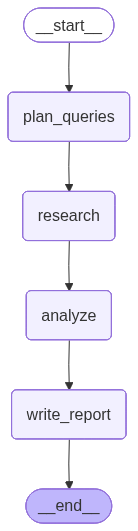

In [17]:
# Display the graph structure
try:
    from IPython.display import Image, display
    display(Image(research_agent.get_graph().draw_mermaid_png()))
except Exception:
    # If visualization dependencies aren't available, print text representation
    print("Graph visualization requires additional dependencies.")
    print("Text representation:")
    print("  [START]")
    print("    |")
    print("  [plan_queries]")
    print("    |")
    print("  [research]")
    print("    |")
    print("  [analyze]")
    print("    |")
    print("  [write_report]")
    print("    |")
    print("  [END]")

### Running the Research Agent

Now let's run our agent on a real research question! We'll provide an initial state with just the research question, and the agent will autonomously:
1. Decompose it into sub-queries
2. Search the web for each sub-query
3. Analyze all the results
4. Write a comprehensive report

Let's try it out:


In [18]:
# Define the research question
research_question = "What are the latest developments in AI agents, and how are they being used in real-world applications?"

# Create the initial state
initial_state = {
    "research_question": research_question,
    "search_queries": [],
    "search_results": [],
    "analysis": "",
    "report": "",
    "sources": []
}

print("="*60)
print("DEEP RESEARCH AGENT")
print("="*60)
print(f"\nResearch question: {research_question}\n")
print("-"*60)

# Run the agent
result = research_agent.invoke(initial_state)

print("\n" + "="*60)
print("RESEARCH COMPLETE")
print("="*60)

DEEP RESEARCH AGENT

Research question: What are the latest developments in AI agents, and how are they being used in real-world applications?

------------------------------------------------------------
Planned 5 sub-queries:
  1. latest developments in AI agents 2023
  2. real-world applications of AI agents 2023
  3. impact of AI agents on industries 2023
  4. AI agents in healthcare case studies 2023
  5. emerging trends in AI agent technology 2023
Searching (1/5): latest developments in AI agents 2023
Searching (2/5): real-world applications of AI agents 2023
Searching (3/5): impact of AI agents on industries 2023
Searching (4/5): AI agents in healthcare case studies 2023
Searching (5/5): emerging trends in AI agent technology 2023

Collected 15 results from 15 unique sources.
Analysis complete.
Analysis length: 4676 characters
Report generated.
Report length: 6514 characters

RESEARCH COMPLETE


### Viewing the Research Report

Let's display the final research report that our agent generated.


In [19]:
from IPython.display import Markdown, display

# Display the report with markdown rendering
print(f"Research Question: {result['research_question']}")
print(f"Sub-queries used: {len(result['search_queries'])}")
print(f"Sources consulted: {len(result['sources'])}")
print(f"Report length: {len(result['report'])} characters")
print("\n" + "="*60 + "\n")

# Render the markdown report
display(Markdown(result["report"]))

Research Question: What are the latest developments in AI agents, and how are they being used in real-world applications?
Sub-queries used: 5
Sources consulted: 15
Report length: 6514 characters




# Latest Developments in AI Agents and Their Real-World Applications

## Executive Summary
The landscape of AI agents is rapidly evolving, with the number of agents increasing from over 50 to more than 900 in just one year. These agents are being integrated into various sectors, including healthcare, customer service, and logistics, demonstrating significant market growth projected to reach $50.31 billion by 2030. However, challenges remain in the full-scale implementation of these technologies, highlighting the need for robust governance and cultural adaptation.

## Key Findings

### Market Growth and Technological Advancements
- **Significant Market Expansion**: The AI agent market is expected to grow substantially, with forecasts estimating a market value of $50.31 billion by 2030 (Result 4). This growth reflects increasing investment and interest in AI technologies across industries.
- **Advancements in Multimodal AI**: Recent developments in multimodal AI are enhancing the capabilities of AI agents, allowing for improved voice processing, video analysis, and image recognition (Result 1). This evolution is crucial for creating more sophisticated and effective agents.
- **Agentic Workflows**: The trend towards "Agentic Workflows" signifies a shift from basic task automation to systems capable of planning, executing, and self-correcting tasks, indicating a move towards greater autonomy in AI agents (Result 13).

### Applications Across Industries
- **Healthcare**: AI agents are revolutionizing healthcare by improving diagnostics, patient management, and operational efficiency. Studies indicate that AI systems can outperform human practitioners in disease detection (Results 10, 11).
- **Customer Service**: Projections suggest that AI agents will manage up to 80% of customer interactions by 2028, showcasing their growing role in enhancing customer experience and operational efficiency (Result 2).
- **Logistics and Operations**: The integration of AI agents with robotics is streamlining warehouse operations and delivery logistics, leading to increased efficiency and reduced operational costs (Results 2, 4).

### Challenges and Adoption
- **Implementation Gaps**: Despite the promising growth of AI agents, many organizations face challenges in transitioning from experimentation to full-scale deployment. A significant number remain in the pilot phase, struggling to scale these technologies effectively (Result 2).
- **Need for Governance Frameworks**: Successful integration of AI agents requires organizations to develop governance frameworks and foster a culture that supports AI adoption (Result 2). This is critical for addressing ethical concerns and ensuring responsible use of AI technologies.

### Contradictions and Gaps in Information
There is a notable contradiction regarding the pace of adoption; while some reports highlight rapid growth, others indicate that many organizations are still in the experimental phase. Furthermore, while the benefits of AI agents are widely discussed, there is a lack of focus on the ethical implications and potential misuse of these technologies, which warrants further investigation.

### Distinguishing Facts from Opinions
Quantifiable facts include the projected market growth of AI agents and specific applications in various sectors, such as healthcare and customer service. Conversely, discussions about the transformative potential of AI agents often contain speculative opinions that may not be universally accepted (Results 2, 9).

### Important Insights
1. **Autonomy and Specialization**: The shift towards more autonomous AI agents capable of complex task execution signifies a major advancement in AI technology, indicating a future where AI plays an integral role in business operations.
2. **Sector-Specific Applications**: The emergence of vertical AI agents tailored to specific industries enhances their effectiveness in addressing unique challenges, suggesting a trend towards specialization in AI solutions.
3. **Implementation Challenges**: The gap between the potential of AI agents and their actual deployment underscores the necessity for organizations to cultivate robust governance frameworks and cultural readiness.
4. **Future Outlook**: As AI agents continue to evolve, their integration into everyday business processes is expected to deepen, fundamentally transforming organizational operations and customer interactions.

## Conclusion
The rapid advancements in AI agents present significant opportunities across various industries, yet successful implementation remains a challenge. Organizations must navigate these complexities with strategic foresight and careful planning to fully leverage the potential of AI agents. The future of AI agents is promising, with the potential to reshape how businesses operate and engage with customers.

## Sources
- [The Impact of AI Agents on Industries](https://www.linkedin.com/posts/alexruperez_the-impact-of-ai-agents-on-industries-activity-7321113637123776513-wxo8)
- [Vertical AI Agents Impact Industries](https://www.ema.ai/additional-blogs/addition-blogs/vertical-ai-agents-impact-industries)
- [Emerging AI Agent Trends](https://fueler.io/blog/emerging-ai-agent-trends-that-will-dominate-the-next-years)
- [Agentic AI Trends](https://www.servicenow.com/products/ai-agents/agentic-ai-trends.html)
- [Emerging Trends in Generative AI](https://blog.charlesit.com/emerging-trends-in-generative-ai-your-guide-to-ai-agents-smart-tech)
- [Future of AI Agents](https://www.mindstudio.ai/blog/future-of-ai-agents/)
- [AI Agents in Healthcare](https://aimultiple.com/ai-agents-in-healthcare)
- [AI Agents in Action](https://toloka.ai/blog/ai-agents-in-action-20-real-world-business-applications-across-industries)
- [AI Agent Update](http://article.sapub.org/10.5923.j.ajis.20251401.02.html)
- [AI Agents: The Next Evolution in Enterprise Automation](https://www.revgenpartners.com/insight-posts/ai-agents-the-next-evolution-in-enterprise-automation/)
- [Real-World Applications of AI Agents](https://www.xcubelabs.com/blog/ai-agents-real-world-applications-and-examples/)
- [AI Agent Use Cases](https://bronson.ai/resources/ai-agent-use-cases/)
- [AI Case Studies in Healthcare](https://tezeract.ai/ai-case-studies-in-healthcare/)
- [AI Agent Update Week](https://www.scribd.com/document/889092756/AI-Agent-Update-Week-May-18)
- [Top AI Agents Use Case for Healthcare in 2025](https://www.upskillist.com/blog/top-ai-agents-use-case-for-healthcare-in-2025/)

### Trying a Custom Research Question

Now it's your turn! Modify the research question below to investigate any topic you're curious about. The agent will run the full pipeline for your question.


In [ ]:
# Try your own research question!
custom_question = "What is the current state of nuclear fusion energy research and when might it become commercially viable?"

custom_state = {
    "research_question": custom_question,
    "search_queries": [],
    "search_results": [],
    "analysis": "",
    "report": "",
    "sources": []
}

print("="*60)
print("DEEP RESEARCH AGENT — Custom Query")
print("="*60)
print(f"\nResearch question: {custom_question}\n")
print("-"*60)

custom_result = research_agent.invoke(custom_state)

print("\n" + "="*60 + "\n")
display(Markdown(custom_result["report"]))

DEEP RESEARCH AGENT — Custom Query

Research question: What is the current state of nuclear fusion energy research and when might it become commercially viable?

------------------------------------------------------------
Planned 5 sub-queries:
  1. current advancements in nuclear fusion energy research 2023
  2. timeline for commercial viability of nuclear fusion energy
  3. major challenges facing nuclear fusion energy development
  4. recent breakthroughs in nuclear fusion technology
  5. comparison of nuclear fusion and renewable energy sources
Searching (1/5): current advancements in nuclear fusion energy research 2023
Searching (2/5): timeline for commercial viability of nuclear fusion energy
Searching (3/5): major challenges facing nuclear fusion energy development
Searching (4/5): recent breakthroughs in nuclear fusion technology
Searching (5/5): comparison of nuclear fusion and renewable energy sources

Collected 15 results from 15 unique sources.
Analysis complete.
Analysis 